In [5]:
import pandas as pd
from itables import init_notebook_mode
import polars as pl
import os
import numpy as np
init_notebook_mode(all_interactive=True)
import plotnine as pn



In [6]:
import sys
sys.path.append("/home/a379i/Scripts")   # path to folder containing the python file

from utils.load_gtf_cgc_dresden import *
from ProteinExpression.load_pr_data import *

In [7]:
sa = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/sample_data/master_drop_sample_annotation_sizeFactorFiltered_0.1.tsv", sep="\t")
sample_id = "2DWXNH"
sa[sa["pid"] == sample_id]

sa["key"] = sa["pid"] +  "." + sa["nct_pid"].str.split("_").str[1]


In [4]:
sv_res = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/predisp_svs.tsv", sep="\t")
sv_res[sv_res["sampleID"] == "978GLK"]

/tmp/ipykernel_231670/631839275.py:1: DtypeWarning: Columns (59) have mixed types. Specify dtype option on import or set low_memory=False.


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [5]:
needed_cols = ["sampleID", "zScore", "pValue", "padjust", "IMPACT", "geneID",  "geneID_short",
               "#Uploaded_variation_snv", "ref_snv", "Allele_snv", "IMPACT_snv", "ANNOTATION_control_snv", "Consequence_snv", "promoterAI_snv",
               "Location_indel", "IMPACT_indel", "ANNOTATION_control_indel", "Consequence_indel",
               "padjust_predisp", "padjust_predisp_extended", ]

py_or_res_aberrant = pd.read_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/all_cohorts/oht_cov_diag_lr_0_0001_epoc200_gpu/or_variants_outliers.parquet",
                                    columns=needed_cols)
py_or_res_aberrant = py_or_res_aberrant.merge(sa[["pid", "Diag", "Oncotree Code", "Oncotree Text", "seq_type"]], right_on="pid", left_on="sampleID")
py_or_res_aberrant = py_or_res_aberrant.merge(extended_dresden_dt, on="geneID_short")

py_or_res_aberrant["gene_sample"] = py_or_res_aberrant["geneID_short"] + "_" + py_or_res_aberrant["sampleID"]
py_or_res_aberrant = py_or_res_aberrant[py_or_res_aberrant["padjust_predisp_extended"] < 0.05]


In [ ]:
cnv_germline = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/germline_cnv_exploded_filtered.tsv", sep="\t")
cnv = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/cnv_exploded_filtered.tsv", sep="\t")
cnv = cnv[(cnv["Type"].notna()) & (cnv["Type"] != "CNN")]




In [44]:
cnv["key"] = cnv["group_name"].str[4:]
cnv_germline["key"] = cnv_germline["group_name"].str[4:]

In [45]:
cnv = cnv.merge(sa[["key"]], on="key", how="inner")
cnv_germline = cnv_germline.merge(sa[["key"]], on="key", how="inner")



In [ ]:
cnv.to_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/cnv_predisp_exploded_filtered.tsv", sep="\t", index=None)
cnv_germline.to_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/germline_cnv_predisp_exploded_filtered.tsv", sep="\t", index=None)


In [9]:
cnv_germline = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/germline_cnv_exploded_filtered.tsv", sep="\t")
cnv = ( pl.scan_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/cnv_exploded_filtered.tsv", separator="\t", infer_schema_length=1000000)
        .filter(pl.col("Type") != "CNN", )
        .collect(engine="streaming")
      ).to_pandas()






In [14]:
gene_annot_dt[gene_annot_dt["gene_type"] == "protein_coding"]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [10]:
cnv["Ggene_annot_dt[gene_annot_dt["gene_type"] == "protein_coding"]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


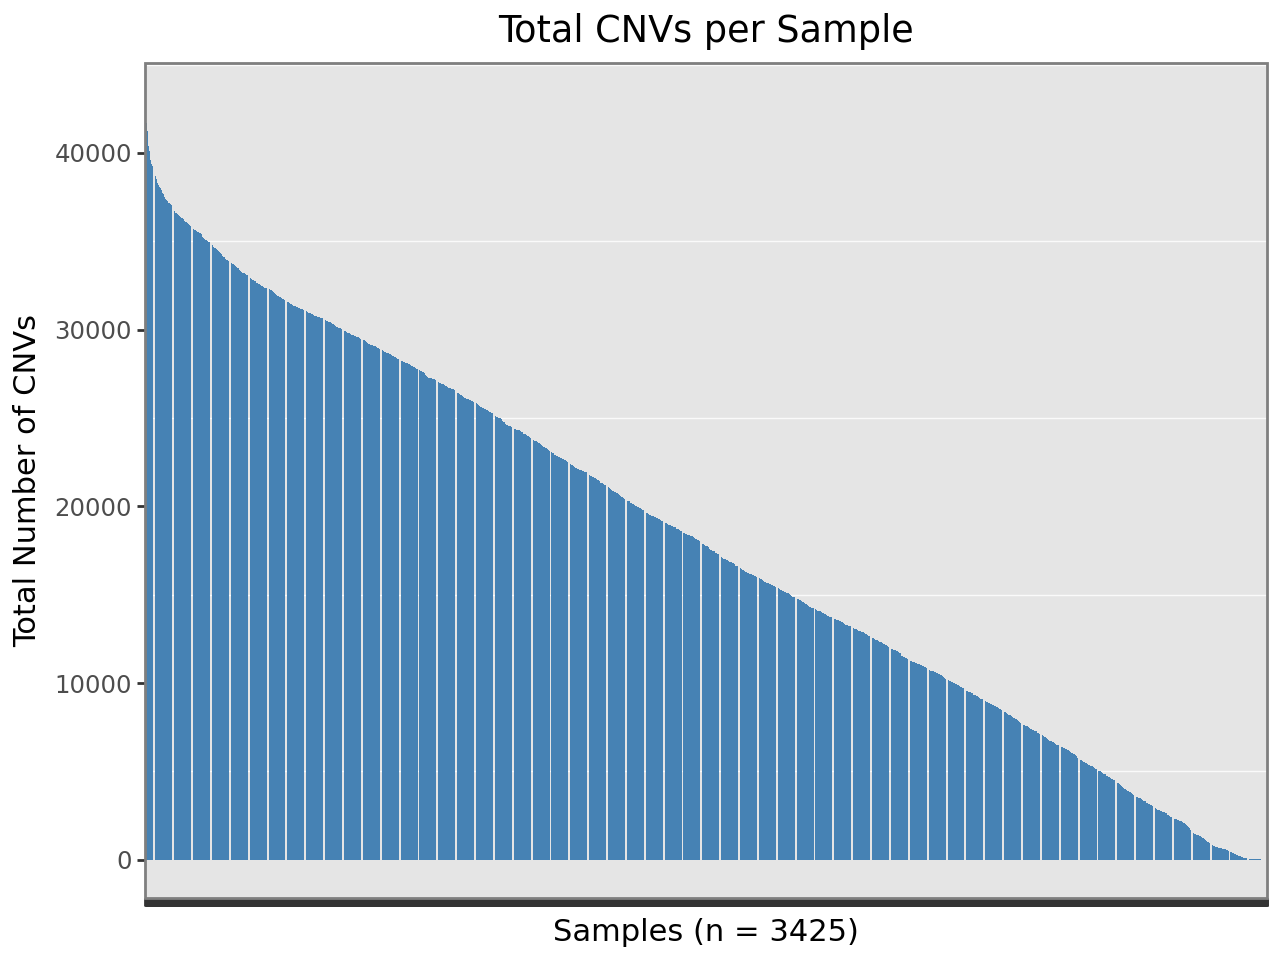

In [16]:
sample_counts = cnv.groupby('group_name').size().reset_index(name='total_cnvs')

# 3. Sort samples by total CNVs (optional but recommended for readability)
sample_counts = sample_counts.sort_values('total_cnvs', ascending=False)
sample_counts['sample'] = pd.Categorical(sample_counts['group_name'], 
                                         categories=sample_counts['group_name'], 
                                         ordered=True)

# 4. Plot
plot = (
    pn.ggplot(sample_counts, pn.aes(x='sample', y='total_cnvs'))
    + pn.geom_col(fill="steelblue")
    + pn.labs(
        title="Total CNVs per Sample",
        x=f"Samples (n = {len(cnv["group_name"].unique())})",
        y="Total Number of CNVs"
    )
    + pn.theme_bw()
    + pn.theme(
        axis_text_x=pn.element_blank() # Rotates sample names so they don't overlap
    )
)
plot

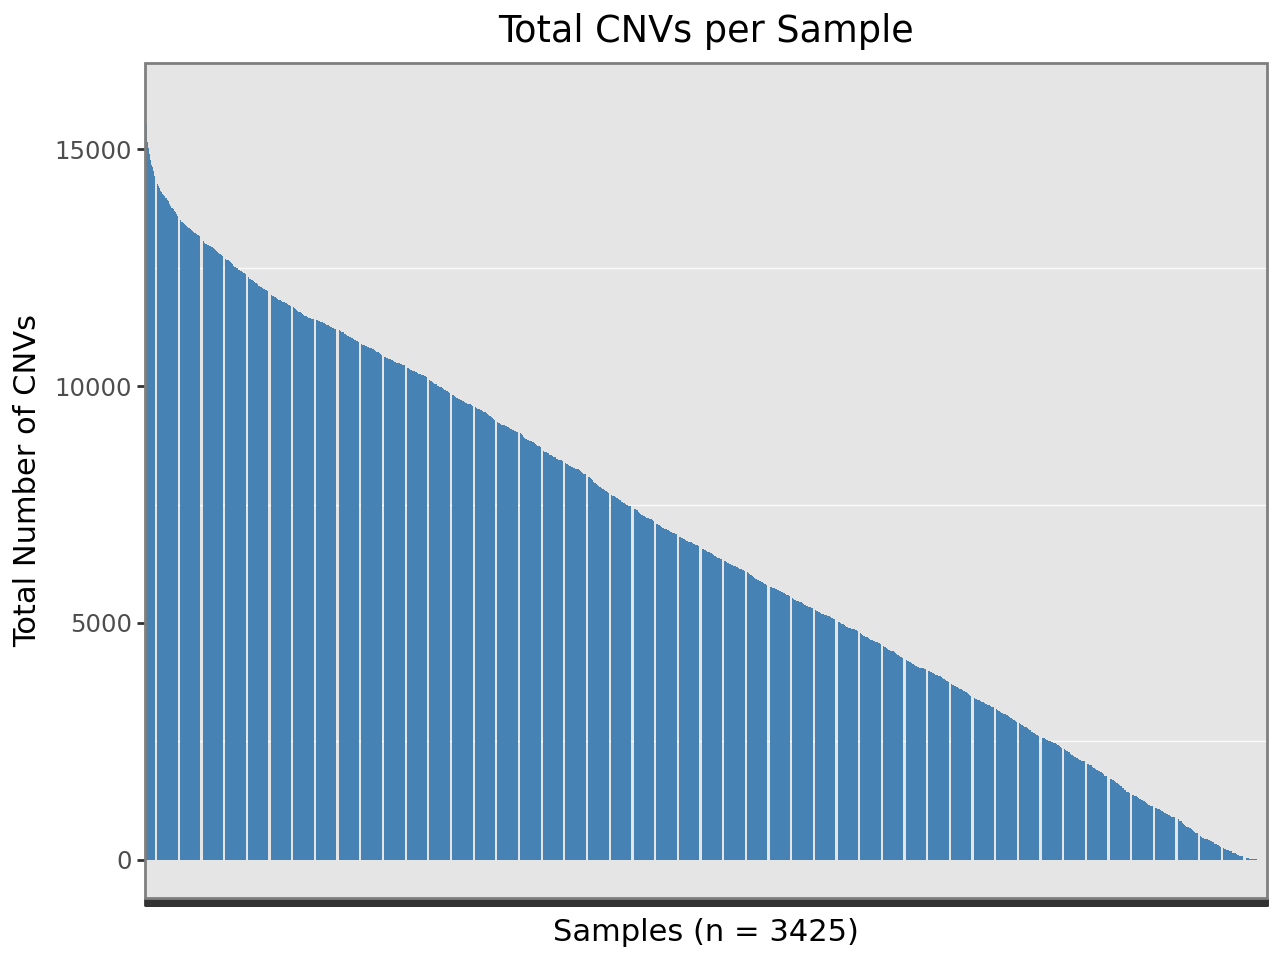

In [19]:
sample_counts = cnv[cnv["Gene"].isin(gene_annot_dt[gene_annot_dt["gene_type"] == "protein_coding"]["gene_name"])].groupby('group_name').size().reset_index(name='total_cnvs')

# 3. Sort samples by total CNVs (optional but recommended for readability)
sample_counts = sample_counts.sort_values('total_cnvs', ascending=False)
sample_counts['sample'] = pd.Categorical(sample_counts['group_name'], 
                                         categories=sample_counts['group_name'], 
                                         ordered=True)

# 4. Plot
plot = (
    pn.ggplot(sample_counts, pn.aes(x='sample', y='total_cnvs'))
    + pn.geom_col(fill="steelblue")
    + pn.labs(
        title="Total CNVs per Sample",
        x=f"Samples (n = {len(cnv["group_name"].unique())})",
        y="Total Number of CNVs"
    )
    + pn.theme_bw()
    + pn.theme(
        axis_text_x=pn.element_blank() # Rotates sample names so they don't overlap
    )
)
plot

In [21]:
sample_counts["total_cnvs"].mean()

np.float64(6683.507759882869)

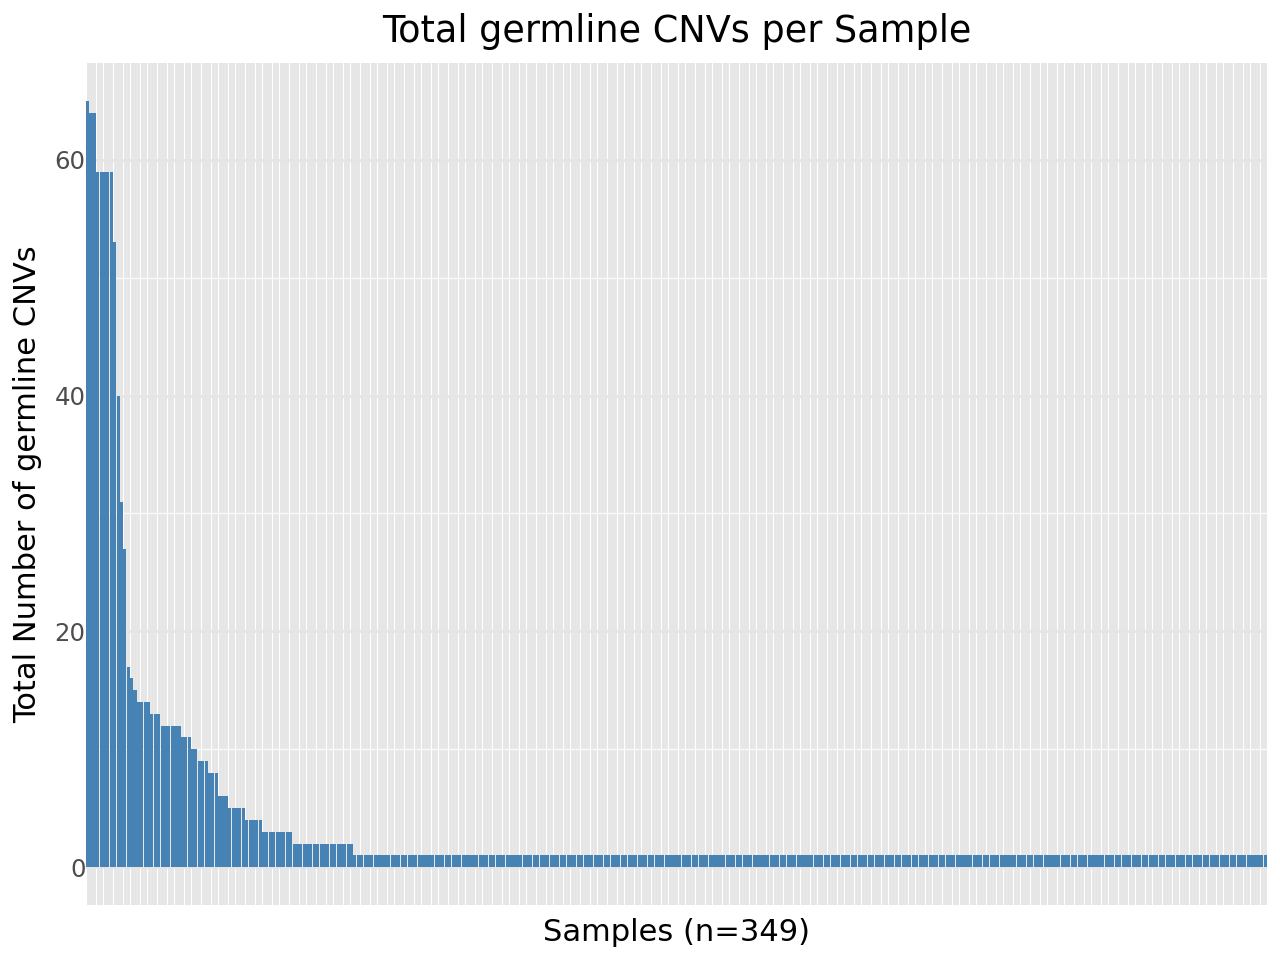

In [52]:
sample_counts = cnv_germline.groupby('group_name').size().reset_index(name='total_cnvs')

# 3. Sort samples by total CNVs (optional but recommended for readability)
sample_counts = sample_counts.sort_values('total_cnvs', ascending=False)
sample_counts['sample'] = pd.Categorical(sample_counts['group_name'], 
                                         categories=sample_counts['group_name'], 
                                         ordered=True)

# 4. Plot
plot = (
    pn.ggplot(sample_counts, pn.aes(x='sample', y='total_cnvs'))
    + pn.geom_col(fill="steelblue")
    + pn.labs(
        title="Total germline CNVs per Sample",

        x=f"Samples (n={len(cnv_germline.group_name.unique())})",
        y="Total Number of germline CNVs"
    )
    + pn.theme_minimal()
    + pn.theme(
        axis_text_x=pn.element_blank() # Rotates sample names so they don't overlap
    )
)
plot

/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


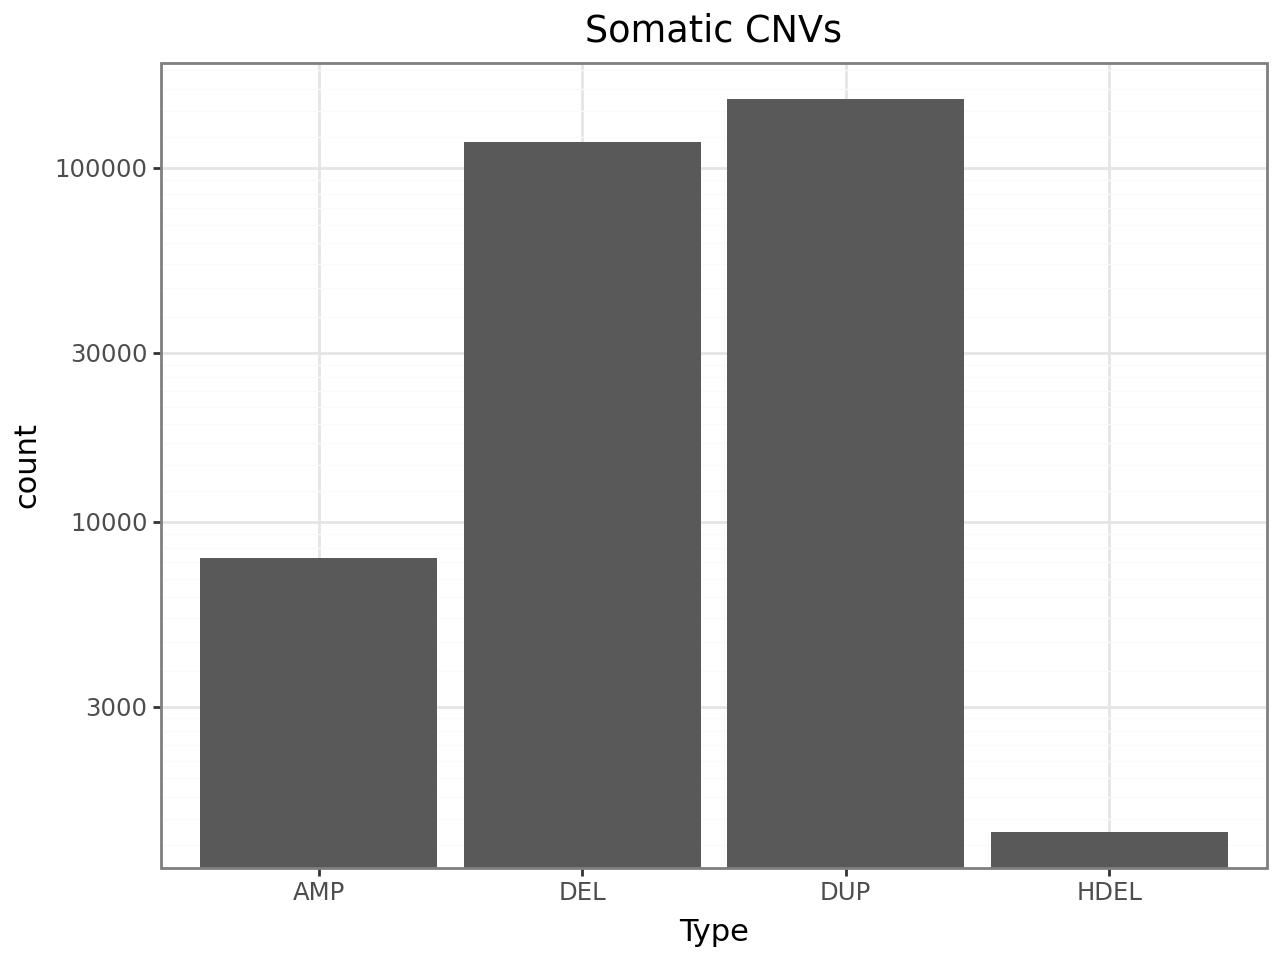

In [53]:
pn.ggplot(cnv[(cnv["Type"].notna()) & (cnv["Type"] != "CNN")]) + pn.geom_bar(pn.aes(x="Type")) + pn.theme_bw() + pn.scale_y_log10() + pn.labs(title="Somatic CNVs")

# pn.ggplot(cnv_germline) + pn.geom_bar(pn.aes(x="Type"), width=0.5) + pn.theme_bw() + pn.labs(title="Germline CNVs")

In [8]:
merged_df = pd.merge(
    py_or_res_aberrant, 
    cnv, 
    left_on=['gene_name', 'sampleID'], 
    right_on=['Gene', 'sampleID'], 
    how='left'
)
merged_df[merged_df["Gene"].notna()]

merged_df = pd.merge(
    merged_df, 
    cnv_germline, 
    left_on=['gene_name', 'sampleID'], 
    right_on=['Gene', 'sampleID'], 
    how='left'
)
merged_df[ (merged_df["zScore"] > 0)]["Type_x"].value_counts()



Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [179]:
merged_df[merged_df["zScore"] < 0]
merged_df[(merged_df["zScore"] < 0) & (~merged_df["Type_x"].str.contains("DEL", na=False)) & (~merged_df["Type_y"].str.contains("DEL", na=False))]
merged_df[(merged_df["zScore"] < 0) & (~merged_df["Type_x"].str.contains("DEL", na=False)) & (~merged_df["Type_y"].str.contains("DEL", na=False)) & (merged_df["IMPACT"].notna())]
merged_df[(merged_df["zScore"] < 0) & (~merged_df["Type_x"].str.contains("DEL", na=False)) & (~merged_df["Type_y"].str.contains("DEL", na=False)) & ((merged_df["ANNOTATION_control_snv"].str.contains("germline", na=False)) | (merged_df["ANNOTATION_control_indel"].str.contains("germline", na=False)))]

merged_df[(merged_df["zScore"] < 0) & (~merged_df["Type_x"].str.contains("DEL", na=False)) & (~merged_df["Type_y"].str.contains("DEL", na=False)) & 
          (((merged_df["ANNOTATION_control_snv"].str.contains("germline", na=False)) & (merged_df["IMPACT_snv"] == "HIGH")) | ((merged_df["ANNOTATION_control_indel"].str.contains("germline", na=False)) & (merged_df["IMPACT_indel"] == "HIGH")))]


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [12]:
# Replace NaN with empty strings before concatenating


merged_df["Type_x"] = [f"Somatic_{x}" if pd.notna(x) and x != "" else "" for x in merged_df["Type_x"]]

# Clean Germline labels
merged_df["Type_y"] = [f"Germline_{y}" if pd.notna(y) and y != "" else "" for y in merged_df["Type_y"]]

# Concatenate with a separator only if both exist
def join_types(row):
    parts = [p for p in [row["Type_x"], row["Type_y"]] if p != ""]
    return " | ".join(parts) if parts else "No CNV"

merged_df["CNV"] = merged_df.apply(join_types, axis=1)


In [52]:
merged_df

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [13]:
merged_df.loc[(merged_df["Consequence_snv"].notna()) & (merged_df["Consequence_indel"].notna()),  "var_type"] = "SNV&indel"
merged_df.loc[(merged_df["var_type"].isna()) & (merged_df["Consequence_snv"].notna()), "var_type"] = "SNV"
merged_df.loc[(merged_df["var_type"].isna()) & (merged_df["Consequence_indel"].notna()), "var_type"] = "indel"
merged_df[merged_df["var_type"].notna() & (merged_df["zScore"] < 0)]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [35]:
merged_df["var_type"].value_counts()

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


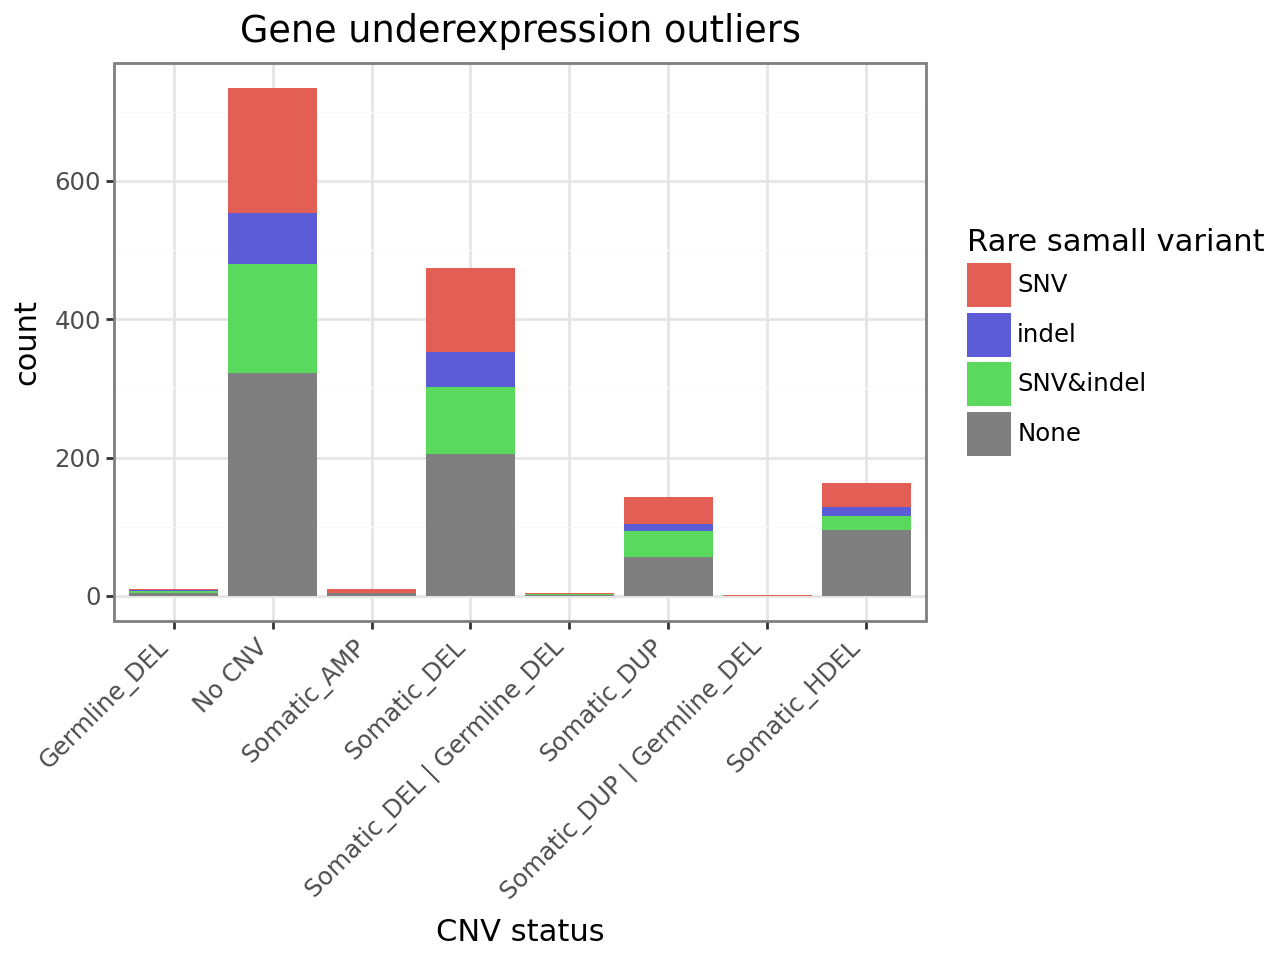

In [40]:
# 1. Fill actual NaNs with the string "nan" so everything is a string
merged_df["var_type"] = merged_df["var_type"].astype(str).replace("nan", "None")

# 2. Define your consistent order (bottom of stack to top)
# Make sure these strings match your data exactly!
category_order = ["SNV", "indel", "SNV&indel", "None"]
merged_df["var_type"] = pd.Categorical(merged_df["var_type"], categories=category_order, ordered=True)
color_map = {
    "None": "#7f7f7f",      # Gray
    "indel": "#5c5cd6",     # Blue
    "SNV&indel": "#59d95d", # Green
    "SNV": "#e35f55"        # Red
}

p = (pn.ggplot(merged_df[merged_df["zScore"] < 0]) + pn.geom_bar(pn.aes(x="CNV", fill="var_type")) + pn.theme_bw() +
    pn.labs(title="Gene underexpression outliers", x="CNV status", fill="Rare samall variant") +
    pn.scale_fill_manual(values=color_map) +
    pn.theme(
        axis_text_x = pn.element_text(rotation=45, hjust=1), # Rotation & horizontal alignment
      )
)
p

In [ ]:
print(merged_df[(merged_df["zScore"] < 0) & (~merged_df["Type_x"].str.contains("DEL")) & (~merged_df["Type_y"].str.contains("DEL"))].shape)
merged_df[(merged_df["zScore"] < 0) & (~merged_df["Type_x"].str.contains("DEL")) & (~merged_df["Type_y"].str.contains("DEL")) & (merged_df["IMPACT"] == "HIGH") & (merged_df["ANNOTATION_control_snv"].str.contains("germline"))]



(898, 66)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


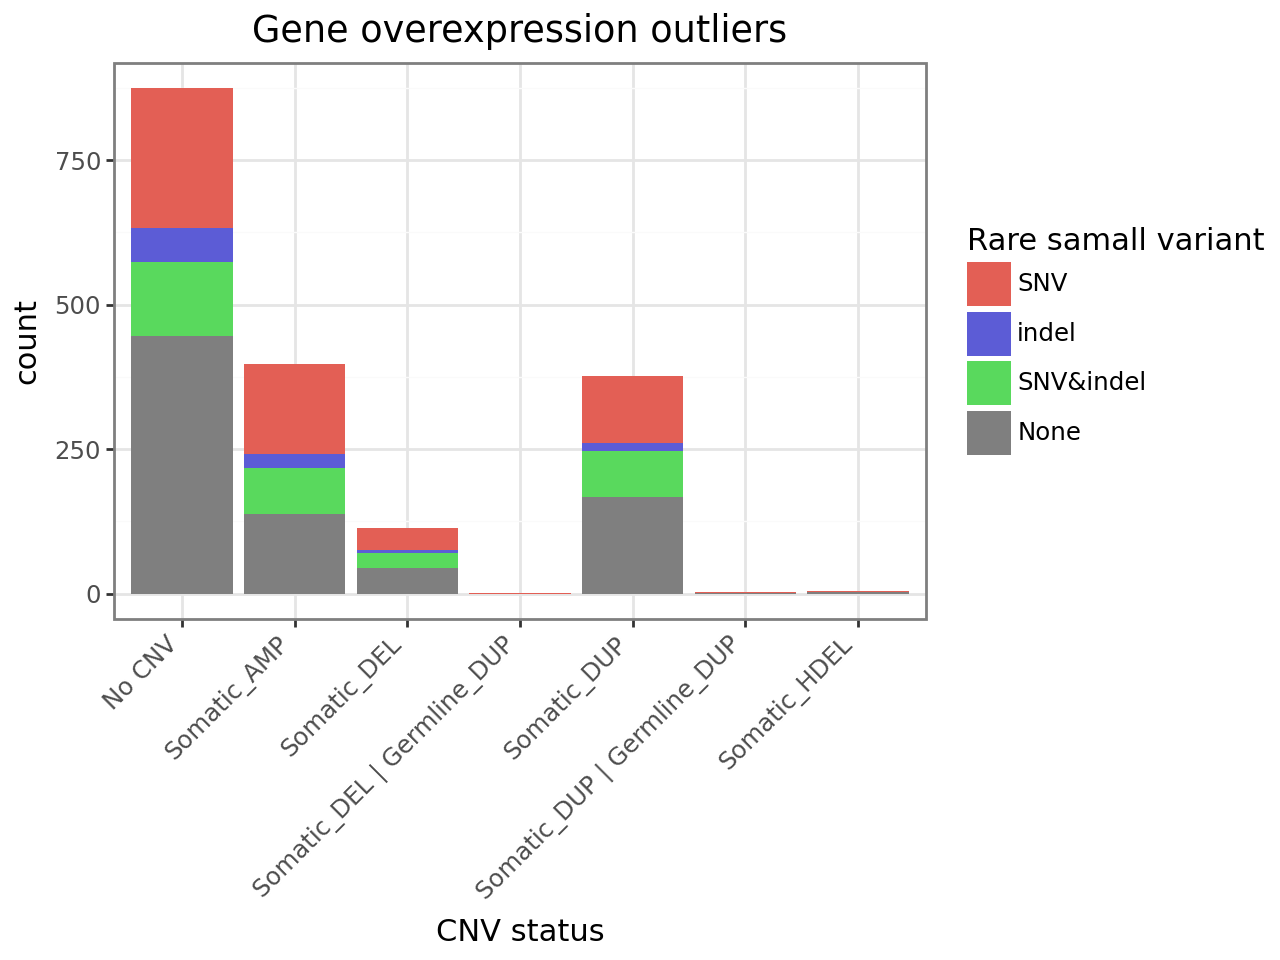

In [41]:
p2 = (pn.ggplot(merged_df[merged_df["zScore"] > 0]) + pn.geom_bar(pn.aes(x="CNV", fill="var_type")) +
      pn.theme_bw()+ pn.labs(title="Gene overexpression outliers", x="CNV status", fill="Rare samall variant") +
      pn.scale_fill_manual(values=color_map) +

      pn.theme(
       axis_text_x = pn.element_text(rotation=45, hjust=1), # Rotation & horizontal alignment
    )
)
p2

In [ ]:
merged_df[merged_df["zScore"] < 0]["Type_x"]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [42]:
pr_output_name = "cov_gaussian_gs_lr_0_001_epoc2000_noInitPCA"

pr_res_all = pd.read_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/protrider_runs/output_" + pr_output_name + "/pr_varinats_outliers.parquet")
pr_res_all = pd.merge(pr_res_all, dresden_dt_cgc[["gene_name", "gene_type", "geneID_short", "ROLE_IN_CANCER", "predisposition_gene"]], right_on="geneID_short", left_on="geneID", how="left")
pr_res_all = pd.merge(pr_res_all, sa, left_on="sampleID", right_on="pid")
pr_res_all = pr_res_all[pr_res_all["padjust_predisp_extended"] < 0.1].drop(columns=["Gene"])

In [43]:
pr_merged_df = pd.merge(
    pr_res_all, 
    cnv, 
    left_on=['proteinID', 'sampleID'], 
    right_on=['Gene', 'sampleID'], 
    how='left'
)
pr_merged_df[pr_merged_df["Gene"].notna()]

pr_merged_df = pd.merge(
    pr_merged_df, 
    cnv_germline, 
    left_on=['proteinID', 'sampleID'], 
    right_on=['Gene', 'sampleID'], 
    how='left'
)
pr_merged_df[ (pr_merged_df["zScore"] > 0)]["Type_x"].value_counts()



Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [44]:
# Replace NaN with empty strings before concatenating


pr_merged_df["Type_x"] = [f"Somatic_{x}" if pd.notna(x) and x != "" else "" for x in pr_merged_df["Type_x"]]

# Clean Germline labels
pr_merged_df["Type_y"] = [f"Germline_{y}" if pd.notna(y) and y != "" else "" for y in pr_merged_df["Type_y"]]

# Concatenate with a separator only if both exist
def join_types(row):
    parts = [p for p in [row["Type_x"], row["Type_y"]] if p != ""]
    return " | ".join(parts) if parts else "No CNV"

pr_merged_df["CNV"] = pr_merged_df.apply(join_types, axis=1)

In [45]:
pr_merged_df.loc[(pr_merged_df["Consequence_snv"].notna()) & (pr_merged_df["Consequence_indel"].notna()),  "var_type"] = "SNV&indel"
pr_merged_df.loc[(pr_merged_df["var_type"].isna()) & (pr_merged_df["Consequence_snv"].notna()), "var_type"] = "SNV"
pr_merged_df.loc[(pr_merged_df["var_type"].isna()) & (pr_merged_df["Consequence_indel"].notna()), "var_type"] = "indel"
pr_merged_df[pr_merged_df["var_type"].notna() & (pr_merged_df["zScore"] < 0)]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


(96, 120)


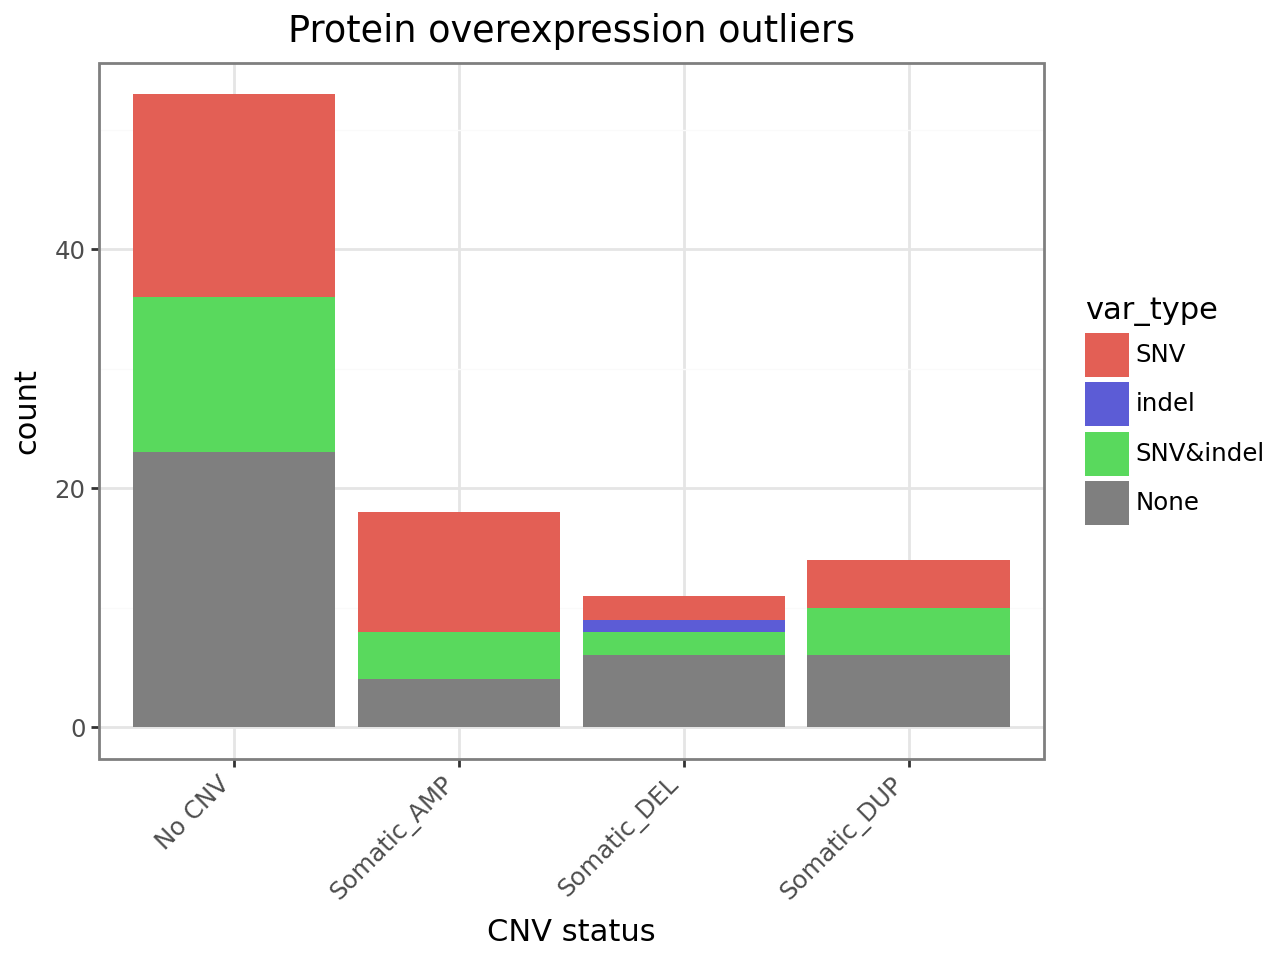

In [48]:
print(pr_merged_df[pr_merged_df["zScore"] > 0].shape )
pr_merged_df["var_type"] = pr_merged_df["var_type"].astype(str).replace("nan", "None")

# 2. Define your consistent order (bottom of stack to top)
# Make sure these strings match your data exactly!
category_order = ["SNV", "indel", "SNV&indel", "None"]
pr_merged_df["var_type"] = pd.Categorical(pr_merged_df["var_type"], categories=category_order, ordered=True)
p3 = (pn.ggplot(pr_merged_df[pr_merged_df["zScore"] > 0]) + pn.geom_bar(pn.aes(x="CNV", fill="var_type")) +
      pn.scale_fill_manual(values=color_map) +
      pn.theme_bw()+ pn.labs(title="Protein overexpression outliers", x="CNV status") + pn.theme(
     axis_text_x = pn.element_text(rotation=45, hjust=1), # Rotation & horizontal alignment
   )
)
p3

(117, 120)


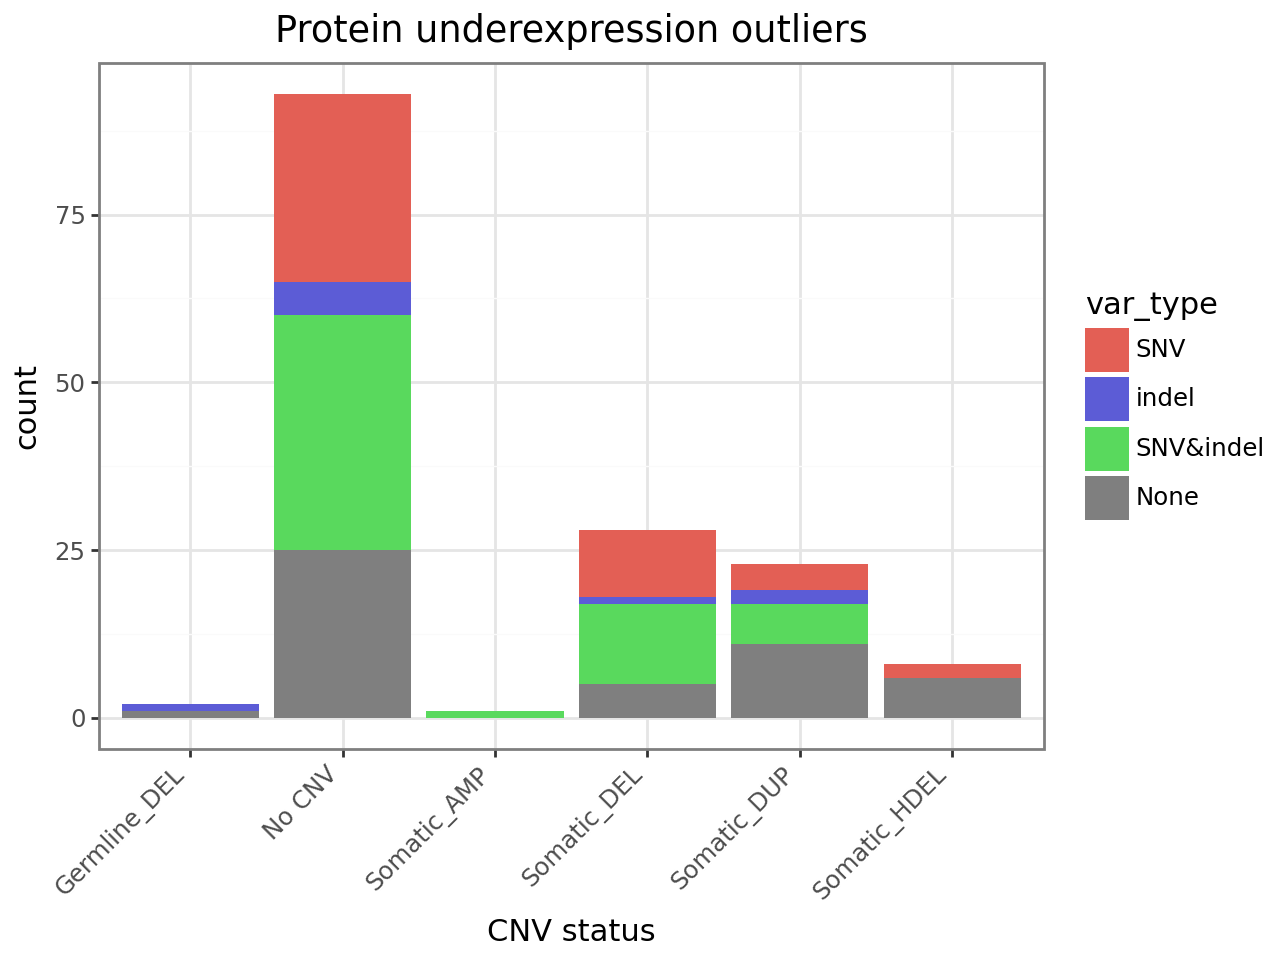

In [51]:
print(pr_merged_df[(pr_merged_df["zScore"] < 0) & (~pr_merged_df["Type_x"].str.contains("DEL")) & (~pr_merged_df["Type_y"].str.contains("DEL"))].shape)
pr_merged_df[(pr_merged_df["zScore"] < 0) & (~pr_merged_df["Type_x"].str.contains("DEL")) & (~pr_merged_df["Type_y"].str.contains("DEL")) & (pr_merged_df["IMPACT"] == "HIGH") & (pr_merged_df["ANNOTATION_control_snv"].str.contains("germline"))]

p4 = (pn.ggplot(pr_merged_df[pr_merged_df["zScore"] < 0]) + pn.geom_bar(pn.aes(x="CNV", fill="var_type")) +
      pn.theme_bw() +  pn.labs(title="Protein underexpression outliers", x="CNV status") +
      pn.scale_fill_manual(values=color_map) +
      pn.theme(
     axis_text_x = pn.element_text(rotation=45, hjust=1), # Rotation & horizontal alignment
   )
)
p4


In [108]:
#sv_res = sv_res.drop_duplicates(subset=["sampleID", "affected_genes", "svtype"])
sv_res["gene1_symbol"] = sv_res["gene1"].str.split("|").str[0]
sv_res["cancer_gene1_symbol"] = sv_res["cancerGene1"].str.split("|").str[0]
sv_res["cancer_gene2_symbol"] = sv_res["cancerGene2"].str.split("|").str[0]

sv_res["gene2_symbol"] = sv_res["gene2"].str.split("|").str[0]


In [ ]:
merged_df_cancer1 = pd.merge(
    py_or_res_aberrant, 
    sv_res, 
    left_on=['gene_name', 'sampleID'], 
    right_on=['affected_genes', 'sampleID'], 
    how='left'
)

# 5. Filter for Underexpression Evidence
# If a gene is underexpressed, we are specifically looking for 'DEL' (Deletions)
# evidence_cancer_1 = merged_df_cancer1[merged_df_cancer1['svtype'] == 'DEL']

# merged_df_cancer2 = pd.merge(
#     merged_df_cancer1, 
#     sv_res, 
#     left_on=['gene_name', 'sampleID'], 
#     right_on=['cancer_gene2_symbol', 'sampleID'], 
#     how='left'
# )

# # 5. Filter for Underexpression Evidence
# # If a gene is underexpressed, we are specifically looking for 'DEL' (Deletions)
# evidence_cancer_2 = merged_df_cancer2[(merged_df_cancer2['svtype_x'] == 'DEL') | (merged_df_cancer2['svtype_y'] == 'DEL')]

merged_df_cancer1[(merged_df_cancer1['svtype'] == 'DEL') & (merged_df_cancer1["affected_genes"] == "NF1")]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [130]:
evidence_cancer_2.drop_duplicates(subset=["gene_sample"])[["padjust_predisp_extended", "IMPACT", "cancer_gene1_symbol_x", "cancer_gene2_symbol_y", "gene_sample", "Diag"]]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [7]:
filtered_somatic_minScore = pd.read_csv("/omics/odcf/project/hipo/hipo_021/sequencing/whole_genome_sequencing/view-by-pid/H021-MNL8UP/cnv_results/paired/tumor_blood/results_ACEseqWorkflow-1.2.8-4_v1_6_2024-06-03_23h13/svs_H021-MNL8UP_filtered_somatic_minEventScore3.tsv", sep="\t")
filtered_somatic_minScore


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [9]:
cnv = pd.read_csv("/omics/odcf/project/hipo/hipo_021/sequencing/whole_genome_sequencing/view-by-pid/H021-MNL8UP/cnv_results/paired/tumor_blood/results_ACEseqWorkflow-1.2.8-4_v1_6_2024-06-03_23h13/H021-MNL8UP_all.cnv.tab.gz", sep="\t") 
cnv

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [157]:
filtered_somatic = pd.read_csv("/omics/odcf/project/hipo/hipo_021/sequencing/exon_sequencing/view-by-pid/H021-978GLK/sv_results/paired/tumor_blood/results_SophiaWorkflow-2.2.3_v1_11_2023-05-22_11h59/svs_H021-978GLK_tumor-blood_filtered_somatic.tsv", sep="\t")
filtered_somatic


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [ ]:
cnv = pd.read_csv("/omics/odcf/project/hipo/hipo_021/sequencing/exon_sequencing/view-by-pid/H021-978GLK/sv_results/paired/tumor_blood/results_SophiaWorkflow-2.2.3_v1_11_2023-05-22_11h59/svs_H021-978GLK_tumor-blood_filtered_somatic.tsv", sep="\t")

In [8]:
filtered = pd.read_csv("/omics/odcf/project/hipo/hipo_021/sequencing/exon_sequencing/view-by-pid/H021-978GLK/sv_results/paired/tumor_blood/results_SophiaWorkflow-2.2.3_v1_11_2023-05-22_11h59/H021-MNL8UP_all.cnv.tab.gz", sep="\t")
filtered

FileNotFoundError: [Errno 2] No such file or directory: '/omics/odcf/project/hipo/hipo_021/sequencing/exon_sequencing/view-by-pid/H021-978GLK/sv_results/paired/tumor_blood/results_SophiaWorkflow-2.2.3_v1_11_2023-05-22_11h59/H021-MNL8UP_all.cnv.tab.gz'

In [162]:
filtered_dedup = pd.read_csv("/omics/odcf/project/hipo/hipo_021/sequencing/exon_sequencing/view-by-pid/H021-978GLK/sv_results/paired/tumor_blood/results_SophiaWorkflow-2.2.3_v1_11_2023-05-22_11h59/svs_H021-978GLK_tumor-blood_filtered_dedup.tsv", sep="\t")
filtered_dedup

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [164]:
tumor_bps = pd.read_csv("/omics/odcf/project/hipo/hipo_021/sequencing/exon_sequencing/view-by-pid/H021-978GLK/sv_results/paired/tumor_blood/results_SophiaWorkflow-2.2.3_v1_11_2023-05-22_11h59/tumor_H021-978GLK_bps.tsv.gz", sep="\t")
tumor_bps

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)
